In [ ]:
from functools import partial

import pandas as pd # библиотека для работы с данными

import jax
import jax.numpy as jnp
from jax import jit, vmap, grad

jnp.set_printoptions(suppress=True)

Предобработка данных

In [ ]:
dataset = pd.read_csv('dataset/data.csv', sep='|')
# Поменяем метки местами
dataset["malware"] = dataset["legitimate"].replace({0:1, 1:0})  # 1 если вредонос
# Отбор признаков
dataset = dataset.drop(['legitimate'],axis=1)  # у нас уже есть столбец malware
dataset = dataset.drop(['Name','md5'],axis=1)   # Отброс данных признаков типа object. Модель будет принимать только признаки типа int и float
X = dataset.drop(['malware'],axis=1).values# Матрица признаков объектов обучающей выборки
y = dataset['malware'].values # Целевая переменная
#JAX jnp.assaray() Convert a python or numpy object to a JAX array.
X = jnp.asarray(X) 
y = jnp.asarray(y)
print(X.shape, y.shape)
# Разбивка данных (70% - обучающие and 30% - тестовые)
from sklearn.model_selection import train_test_split # Функция для разделения выборки на обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.3, stratify = y)
#стандартизация признакового пространства
x_mean = X_train.mean(axis=0)
x_std = X_train.std(axis=0)
X_train = (X_train - x_mean) / x_std
X_test = (X_test - x_mean) / x_std

assert isinstance(X_train, jax.Array)  #JAX returns True both inside and outside traced functions.
assert isinstance(y_train, jax.Array)

(138047, 54) (138047,)


Линейный классификатор

In [ ]:
def linear(x, w, b):
    return #TODO W @ x + b
def softmax(z):
    return #TODO

def logistic_regression(X, w, b):
    return #TODO

In [76]:
# Initialize random model coefficients
key = jax.random.PRNGKey(0)
key, w_key, b_key = jax.random.split(key, 3)
k = 2 # количество классов = 2
w = jax.random.normal(w_key, (X_train.shape[1], k)) * 10**-8 
b = jax.random.normal(b_key, (k,))  * 10**-8
print(w, b)

[[-0.         -0.        ]
 [-0.00000001  0.00000001]
 [-0.         -0.        ]
 [-0.00000001  0.00000002]
 [ 0.00000001 -0.00000001]
 [-0.         -0.00000001]
 [ 0.00000001 -0.00000001]
 [ 0.          0.00000002]
 [ 0.          0.00000001]
 [ 0.00000001 -0.00000001]
 [-0.00000001  0.00000001]
 [ 0.          0.00000001]
 [-0.         -0.        ]
 [ 0.         -0.00000001]
 [ 0.00000001  0.00000001]
 [-0.00000001 -0.00000002]
 [ 0.00000002 -0.00000001]
 [ 0.         -0.00000001]
 [ 0.00000001 -0.        ]
 [-0.          0.00000001]
 [-0.00000002 -0.00000001]
 [-0.00000001  0.        ]
 [ 0.         -0.        ]
 [-0.00000001 -0.00000003]
 [-0.         -0.        ]
 [ 0.          0.00000001]
 [-0.00000001  0.        ]
 [ 0.         -0.        ]
 [ 0.         -0.00000002]
 [ 0.00000004 -0.00000002]
 [ 0.00000001  0.        ]
 [-0.          0.00000002]
 [ 0.         -0.00000001]
 [-0.00000001 -0.00000001]
 [-0.         -0.        ]
 [ 0.00000001  0.00000001]
 [ 0.00000001 -0.00000001]
 

In [77]:
#forward
y_hat = logistic_regression(X_train[:3], w, b)
y_hat

Array([[0.5, 0.5],
       [0.5, 0.5],
       [0.5, 0.5]], dtype=float32)

To select one element from each row of a 2D NumPy array based on an array of indices, you can use NumPy's advanced indexing. Here's how you can do it:

### Example:

```python
import numpy as np

# Example 2D array
array = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Array of indices (one index for each row)
indices = np.array([0, 2, 1])

# Select one element from each row based on the indices
selected_elements = array[np.arange(array.shape[0]), indices]

print(selected_elements)
```

### Explanation:
1. `np.arange(array.shape[0])` generates an array of row indices `[0, 1, 2]` (assuming the array has 3 rows).
2. `indices` is the array of column indices `[0, 2, 1]` for each row.
3. `array[np.arange(array.shape[0]), indices]` selects the element at the specified row and column for each row.

### Output:
```
[1 6 8]
```

### Breakdown:
- For row 0, it selects the element at column 0: `1`.
- For row 1, it selects the element at column 2: `6`.
- For row 2, it selects the element at column 1: `8`.

This method works efficiently for any 2D NumPy array and corresponding array of indices.

In [78]:
# Training loss is the negative log-likelihood of the training examples.
def log_loss(y_hat, y):
    label_probs =  y_hat[jnp.arange(y_hat.shape[0]), y] + 10**-8 # add 10**8 to exclude log(0)
    return jnp.mean(-jnp.log(label_probs))

In [ ]:
def loss_fn(w, b):
    return #TODO
#another_way
loss_fn_prime = lambda w, b: log_loss(logistic_regression(X_train, w, b), y_train)
#jitted version
loss_fn_jitted = jax.jit(loss_fn)
#check with initial w and b
loss_fn(w, b), loss_fn_prime(w, b), loss_fn_jitted(w, b)

In [80]:
#backward
w_grad, b_grad = grad(loss_fn, argnums=(0,1))(w, b)
w_grad, b_grad

(Array([[-0.2512375 ,  0.2512375 ],
        [-0.25121808,  0.25121808],
        [-0.10192609,  0.10192609],
        [-0.00854809,  0.00854809],
        [ 0.06743728, -0.06743728],
        [-0.00635894,  0.00635894],
        [ 0.0023316 , -0.0023316 ],
        [ 0.02975356, -0.02975355],
        [-0.00038847,  0.00038847],
        [ 0.00276487, -0.00276487],
        [ 0.00113175, -0.00113175],
        [ 0.        ,  0.        ],
        [ 0.00140239, -0.00140239],
        [-0.05675299,  0.05675299],
        [-0.19339994,  0.19339997],
        [-0.00089412,  0.00089412],
        [-0.0384589 ,  0.03845889],
        [-0.0379456 ,  0.0379456 ],
        [-0.17319596,  0.17319596],
        [-0.07632361,  0.07632361],
        [ 0.00188857, -0.00188857],
        [-0.0055656 ,  0.0055656 ],
        [ 0.08947105, -0.08947105],
        [-0.2375155 ,  0.2375155 ],
        [ 0.28851223, -0.28851223],
        [ 0.23352979, -0.23352979],
        [ 0.00161173, -0.00161173],
        [ 0.07131691, -0.071

In [81]:
#forward and backward simultaneously
loss_value, (w_grad, b_grad) = jax.value_and_grad(loss_fn_jitted, (0, 1))(w, b)
print('loss value', loss_value)
print('w_grad shape', w_grad.shape)
#jitted version 

loss value 0.69314706
w_grad shape (54, 2)


In [ ]:
#gradient descent
jax.config.update("jax_debug_nans", False)
alpha = 0.01
key, w_key, b_key = jax.random.split(key, 3)
w = jax.random.normal(w_key, (X_train.shape[1], k)) * 10**-8 
b = jax.random.normal(b_key, (k,))  * 10**-8
loss_values = [] #stats for plotting
for i in range(1 * 10**4):
    loss_value, (w_grad, b_grad) = j#TODO
    loss_values.append(loss_value)

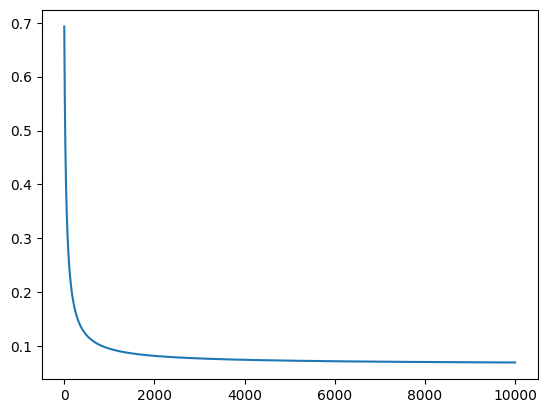

In [86]:
import matplotlib.pyplot as plt
plt.plot(loss_values)
plt.show()

In [89]:
y_pred = logistic_regression(X_test, w, b) > 0.5
y_pred, y_test

(Array([[False,  True],
        [ True, False],
        [ True, False],
        ...,
        [ True, False],
        [False,  True],
        [ True, False]], dtype=bool),
 Array([1, 0, 0, ..., 0, 1, 0], dtype=int32))

#### Нейронные сети с flax

In [7]:
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import optax

In [7]:
# Initialize random model coefficients
key = jax.random.PRNGKey(0)
key, model_rng = jax.random.split(key, 2)

In [ ]:
# Write your network’s logic directly within a single “forward pass” method annotated with nn.compact. 
# This allows you to define your whole module in a single method, and “co-locate” submodules and variables next to where they are used.
class Model(nn.Module):
    out_dims: int
    @nn.compact
    def __call__(self,x):
        #TODO
        return x    

In [12]:
# Parameters are not stored with the models themselves. #
# Need to initialize parameters by calling the init function, using a PRNGKey and dummy input data.
model = Model(out_dims=2)
init_x = jnp.zeros((1, X.shape[1]))
params = model.init(model_rng, init_x)
jax.tree_util.tree_map(lambda x: x.shape, params)

{'params': {'Dense_0': {'bias': (16,), 'kernel': (54, 16)},
  'Dense_1': {'bias': (8,), 'kernel': (16, 8)},
  'Dense_2': {'bias': (2,), 'kernel': (8, 2)}}}

In [20]:
# To conduct a forward pass with the model with a given set of parameters (which are never stored with the model), 
# we just use the `apply` method by providing it the parameters to use as well as the input:
model.apply(params, init_x)

Array([[0., 0.]], dtype=float32)

In [16]:
# use the Module.tabulate method to visualize a table of the model layers by passing an RNG key and template  input.
key, tabulate_rng = jax.random.split(key, 2)
print(model.tabulate(tabulate_rng, init_x))


                                Model Summary                                
┏━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module ┃ inputs        ┃ outputs       ┃ params                 ┃
┡━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│         │ Model  │ float32[1,54] │ float32[1,2]  │                        │
├─────────┼────────┼───────────────┼───────────────┼────────────────────────┤
│ Dense_0 │ Dense  │ float32[1,54] │ float32[1,16] │ bias: float32[16]      │
│         │        │               │               │ kernel: float32[54,16] │
│         │        │               │               │                        │
│         │        │               │               │ 880 (3.5 KB)           │
├─────────┼────────┼───────────────┼───────────────┼────────────────────────┤
│ Dense_1 │ Dense  │ float32[1,16] │ float32[1,8]  │ bias: float32[8]       │
│         │        │               │               │ kernel: fl

Learn through `optax`

Basic usage of Optax is straightforward:

1. Choose an optimization method (e.g. `optax.adam`).

2. Create optimizer state from parameters (for the Adam optimizer, this state will contain the momentum values).

3. Compute the gradients of your loss with `jax.value_and_grad()`.

4. At every iteration, call the Optax update function to update the internal optimizer state and create an update to the parameters. Then add the update to the parameters with Optax’s `apply_updates` method.


In [18]:
optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(params)
jax.tree_util.tree_map(lambda x: x.shape, opt_state)

(ScaleByAdamState(count=(), mu={'params': {'Dense_0': {'bias': (16,), 'kernel': (54, 16)}, 'Dense_1': {'bias': (8,), 'kernel': (16, 8)}, 'Dense_2': {'bias': (2,), 'kernel': (8, 2)}}}, nu={'params': {'Dense_0': {'bias': (16,), 'kernel': (54, 16)}, 'Dense_1': {'bias': (8,), 'kernel': (16, 8)}, 'Dense_2': {'bias': (2,), 'kernel': (8, 2)}}}),
 EmptyState())

In [41]:
@jax.jit
def compute_loss(params, X, y):
    logits = model.apply(params, X)
    return optax.losses.softmax_cross_entropy_with_integer_labels(logits = logits, labels = y).mean()

In [42]:
compute_loss(params, X_train, y_train).mean()

Array(0.81815016, dtype=float32)

In [49]:
loss_grad_fn = jax.value_and_grad(compute_loss,  argnums=0,) #argnums (int | Sequence[int]) – Optional, integer or sequence of integers. Specifies which positional argument(s) to differentiate with respect to (default 0).
grads = loss_grad_fn(params, X_train, y_train)
jax.tree_util.tree_map(lambda x: x.shape, grads)

((),
 {'params': {'Dense_0': {'bias': (16,), 'kernel': (54, 16)},
   'Dense_1': {'bias': (8,), 'kernel': (16, 8)},
   'Dense_2': {'bias': (2,), 'kernel': (8, 2)}}})

A complete picture

In [52]:
class Model(nn.Module):
    out_dims: int
    @nn.compact
    def __call__(self,x):
        x = nn.Dense(16)(x)
        x = nn.relu(x)
        x = nn.Dense(8)(x)
        x = nn.relu(x)
        x = nn.Dense(self.out_dims)(x)
        return x  
model = Model(out_dims=2)
#init params
init_x = jnp.zeros((1, X.shape[1]))
params = model.init(model_rng, init_x)
#init optimizer
optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(params)
#loss function and gradient
@jax.jit
def compute_loss(params, X, y):
    return optax.losses.softmax_cross_entropy_with_integer_labels(logits = model.apply(params, X), labels = y).mean()
loss_grad_fn = jax.value_and_grad(compute_loss,  argnums=0,)
#gradient descent
loss_values = [] 
for i in range(10**4):
  loss_val, grads = loss_grad_fn(params, X_train, y_train)
  updates, opt_state = optimizer.update(grads, opt_state)
  params =jax.tree.map(lambda x,y: x+y, params, (updates))
  #OR 
  # params = optax.apply_updates(params, updates)
  if i % 10 == 0:
    loss_values.append(loss_val)

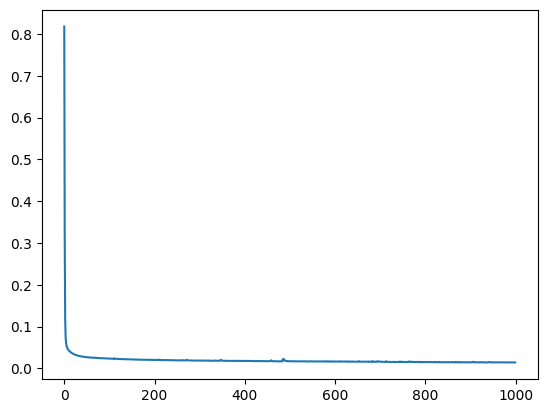

In [54]:
import matplotlib.pyplot as plt
plt.plot(loss_values)
plt.show()

In [60]:
#testing
y_pred = jnp.argmax(model.apply(params, X_test), axis=1)
jnp.mean(y_pred == y_test)

[0 1 1 ... 0 1 1]


Array(0.9903658, dtype=float32)

A common pattern in Flax is to create a single dataclass that represents the entire training state, including step number, parameters, and optimizer state.

Because this is such a common pattern, Flax provides the class `flax.training.train_state.TrainState` that serves most basic usecases.


In [5]:
from flax.training.train_state import TrainState

In [8]:
class Model(nn.Module):
    out_dims: int
    @nn.compact
    def __call__(self,x):
        x = nn.Dense(16)(x)
        x = nn.relu(x)
        x = nn.Dense(8)(x)
        x = nn.relu(x)
        x = nn.Dense(self.out_dims)(x)
        return x     
rng = jax.random.key(0)
rng, model_rng = jax.random.split(rng)
model = Model(out_dims=2)
init_x = jnp.zeros((1, X.shape[1]))
init_model_params = model.init(model_rng, init_x)
optimizer = optax.adam(1e-3)

In [9]:
train_state_init = TrainState.create(apply_fn=model.apply,
                                     params=init_model_params['params'],
                                     tx=optimizer,)

In [10]:
# keys of tarin_state
flattened, _ = jax.tree_util.tree_flatten_with_path(train_state_init) #tree_flatten_with_path with keypaths
for key_path, value in flattened:
    print(jax.tree_util.keystr(key_path))

.step
.params['Dense_0']['bias']
.params['Dense_0']['kernel']
.params['Dense_1']['bias']
.params['Dense_1']['kernel']
.params['Dense_2']['bias']
.params['Dense_2']['kernel']
.opt_state[0].count
.opt_state[0].mu['Dense_0']['bias']
.opt_state[0].mu['Dense_0']['kernel']
.opt_state[0].mu['Dense_1']['bias']
.opt_state[0].mu['Dense_1']['kernel']
.opt_state[0].mu['Dense_2']['bias']
.opt_state[0].mu['Dense_2']['kernel']
.opt_state[0].nu['Dense_0']['bias']
.opt_state[0].nu['Dense_0']['kernel']
.opt_state[0].nu['Dense_1']['bias']
.opt_state[0].nu['Dense_1']['kernel']
.opt_state[0].nu['Dense_2']['bias']
.opt_state[0].nu['Dense_2']['kernel']


In [44]:
@jax.jit
def train_step(state, 
               notused=None,
               batch=(X_train, y_train),
               ):
  """Train for a single step."""
  X_batch, y_batch = batch
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, X_batch)
    loss =  optax.losses.softmax_cross_entropy_with_integer_labels(logits = logits, labels = y_batch).mean()
    return loss
  loss_value, grads  = jax.value_and_grad(loss_fn)(state.params)
  state = state.apply_gradients(grads=grads)
  return state, loss_value

In [45]:
train_state, loss = train_step(train_state_init,
                               # (X_train, y_train),
                               )

In [50]:
from functools import partial
train_state, loss_vals = jax.lax.scan(train_step, train_state_init,  length=10**4)

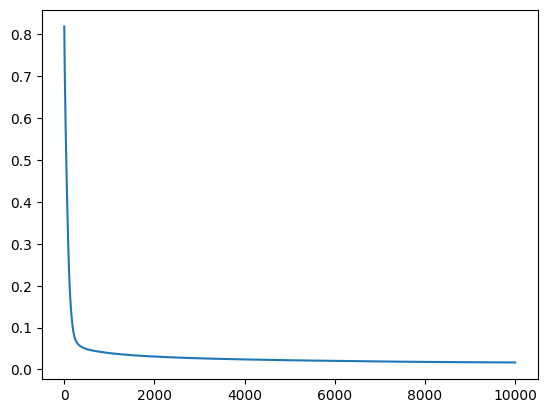

In [51]:
import matplotlib.pyplot as plt
plt.plot(loss_vals)
plt.show()